# Exploratory Data Analysis (EDA) on Open-Meteo Dataset

In [1]:
import pandas as pd

from src.descriptions import aq_measurements, aq_descriptions
from src.eda import understand_features, assess_features, find_central_tendency, measure_variability, \
    visualize_distribution, correlate_features, scatter_plot_features
from src.enums import aq_keys, files

aq = pd.read_csv(files['data/02-28-open-meteo-base.csv'])

## Understand air quality features
Identify what kind of information is in each column, such as measurement and description.

In [2]:
understand_features(aq, aq_measurements, aq_descriptions)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23208 entries, 0 to 23207
Data columns (total 20 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   time                             23208 non-null  object 
 1   us_aqi (USAQI)                   23208 non-null  int64  
 2   us_aqi_pm2_5 (USAQI)             23208 non-null  int64  
 3   us_aqi_pm10 (USAQI)              23208 non-null  int64  
 4   us_aqi_nitrogen_dioxide (USAQI)  23208 non-null  int64  
 5   us_aqi_carbon_monoxide (USAQI)   23208 non-null  int64  
 6   us_aqi_ozone (USAQI)             23208 non-null  int64  
 7   us_aqi_sulphur_dioxide (USAQI)   23208 non-null  int64  
 8   methane (μg/m³)                  11624 non-null  float64
 9   uv_index_clear_sky ()            23208 non-null  float64
 10  uv_index ()                      23208 non-null  float64
 11  dust (μg/m³)                     23208 non-null  int64  
 12  aerosol_optical_de

,Measurement Type,Description
time,interval,Time of the measurement.
us_aqi (USAQI),ordinal,Air Quality Index is the overall standardized ...
us_aqi_pm2_5 (USAQI),ordinal,AQI for PM2.5 particles.
us_aqi_pm10 (USAQI),ordinal,AQI for PM10 particles.
us_aqi_nitrogen_dioxide (USAQI),ordinal,AQI for Nitrogen Dioxide.
us_aqi_carbon_monoxide (USAQI),ordinal,AQI for Carbon Monoxide.
us_aqi_ozone (USAQI),ordinal,AQI for Ozone.
us_aqi_sulphur_dioxide (USAQI),ordinal,AQI for Sulphur Dioxide.
methane (μg/m³),ratio,A potent greenhouse gas that increases ozone l...
uv_index_clear_sky (),ratio,Measurement of the intensity of ultraviolet ra...


## Pre-narrow air quality data features
Based on feature descriptions, identify which features are unnecessary, and remove them to focus on relevant features and avoid wasting time.

In [3]:
# No column will be dropped.
aq_preview = aq.copy()
aq_preview['null_count'] = aq_preview.isnull().sum(axis=1)
aq_preview.sort_values('null_count', ascending=True).head(3).drop('null_count', axis=1)

,time,us_aqi (USAQI),us_aqi_pm2_5 (USAQI),us_aqi_pm10 (USAQI),us_aqi_nitrogen_dioxide (USAQI),us_aqi_carbon_monoxide (USAQI),us_aqi_ozone (USAQI),us_aqi_sulphur_dioxide (USAQI),methane (μg/m³),uv_index_clear_sky (),uv_index (),dust (μg/m³),aerosol_optical_depth (),ozone (μg/m³),sulphur_dioxide (μg/m³),nitrogen_dioxide (μg/m³),carbon_dioxide (ppm),pm2_5 (μg/m³),carbon_monoxide (μg/m³),pm10 (μg/m³)
11603,2024-10-26 11:00,61,61,23,6,5,18,4,1388.0,4.65,4.25,0,0.03,86,7.3,11.7,459.0,6.2,292,9.2
15475,2025-04-05 19:00,53,53,17,13,2,50,3,1454.0,0.00,0.00,3,0.10,67,5.5,25.9,463.0,14.3,335,17.7
15474,2025-04-05 18:00,53,53,16,9,2,50,3,1433.0,0.05,0.05,3,0.10,85,5.1,18.5,458.0,12.7,301,16.2


## Assess air quality features

Document anomalies such as missing and NaN values. This will be referenced when fixing the data.

In [4]:
display(assess_features(aq, aq_measurements))

aq_assessment_no_time = aq.drop(columns = ['time'])
duplicated_rows = aq_assessment_no_time.duplicated().sum()
print("Duplicated Rows: " + str(duplicated_rows))

,Null Count,Null Percentage,Measurement Type,Duplicate Count,Duplicate Percentage
time,0,0.00,interval,0,0.00
us_aqi (USAQI),0,0.00,ordinal,23111,99.58
us_aqi_pm2_5 (USAQI),0,0.00,ordinal,23119,99.62
us_aqi_pm10 (USAQI),0,0.00,ordinal,23178,99.87
us_aqi_nitrogen_dioxide (USAQI),0,0.00,ordinal,23170,99.84
us_aqi_carbon_monoxide (USAQI),0,0.00,ordinal,23197,99.95
us_aqi_ozone (USAQI),0,0.00,ordinal,23101,99.54
us_aqi_sulphur_dioxide (USAQI),0,0.00,ordinal,23196,99.95
methane (μg/m³),11584,49.91,ratio,11101,47.83
uv_index_clear_sky (),0,0.00,ratio,22986,99.04


Duplicated Rows: 0


## Find central tendency of air quality features
Determine if the data is symmetrical. If the data is skewed, a more robust scaling method should be used, like log scaling.

In [5]:
find_central_tendency(aq, aq_measurements)

,Measurement Type,Mean,Median,Skewness,Skew Direction
time,interval,N/A,N/A,N/A,N/A
us_aqi (USAQI),ordinal,40.32,38.0,0.807161,Moderately Right Skewed
us_aqi_pm2_5 (USAQI),ordinal,37.09,36.0,0.390434,Symmetrical
us_aqi_pm10 (USAQI),ordinal,11.36,11.0,0.671976,Moderately Right Skewed
us_aqi_nitrogen_dioxide (USAQI),ordinal,8.2,5.0,1.273532,Highly Right Skewed
us_aqi_carbon_monoxide (USAQI),ordinal,2.36,2.0,1.753234,Highly Right Skewed
us_aqi_ozone (USAQI),ordinal,25.05,25.0,0.578461,Moderately Right Skewed
us_aqi_sulphur_dioxide (USAQI),ordinal,1.52,1.0,1.499424,Highly Right Skewed
methane (μg/m³),ratio,1469.48,1445.0,1.517563,Highly Right Skewed
uv_index_clear_sky (),ratio,1.43,0.0,1.87841,Highly Right Skewed


## Measure variability of air quality features

Determine variability using both mean and median-based methods.

In [6]:
measure_variability(aq)

,Feature,q1,q3,iqr,std_dev,cv,lower_limit,upper_limit
0,us_aqi (USAQI),31.00,49.00,18.00,12.61,0.31,4.00,76.00
1,us_aqi_pm2_5 (USAQI),26.00,48.00,22.00,14.68,0.40,-7.00,81.00
2,us_aqi_pm10 (USAQI),8.00,14.00,6.00,4.50,0.40,-1.00,23.00
3,us_aqi_nitrogen_dioxide (USAQI),2.00,12.00,10.00,7.55,0.92,-13.00,27.00
4,us_aqi_carbon_monoxide (USAQI),2.00,3.00,1.00,1.14,0.48,0.50,4.50
5,us_aqi_ozone (USAQI),16.00,33.00,17.00,12.25,0.49,-9.50,58.50
6,us_aqi_sulphur_dioxide (USAQI),1.00,2.00,1.00,1.04,0.68,-0.50,3.50
7,methane (μg/m³),1403.00,1510.00,107.00,91.10,0.06,1242.50,1670.50
8,uv_index_clear_sky (),0.00,1.95,1.95,2.42,1.70,-2.92,4.88
9,uv_index (),0.00,1.55,1.55,2.30,1.78,-2.33,3.88


## Visualize distribution of air quality features

Visualize the distribution of each feature to understand the data better and identify any anomalies or patterns.

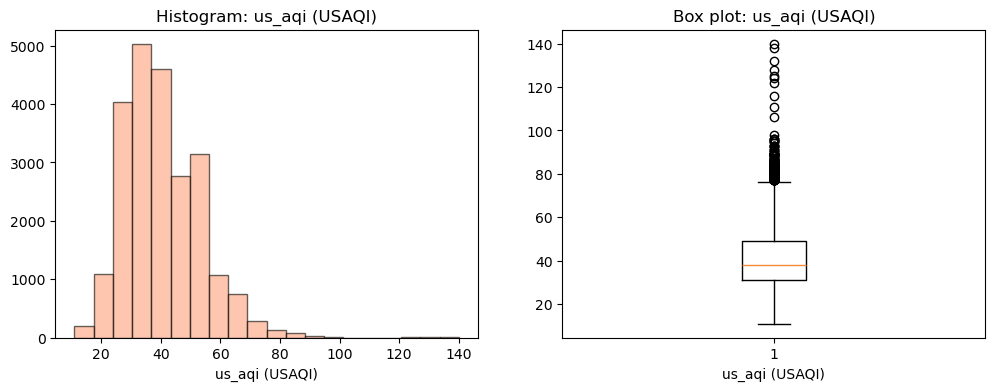

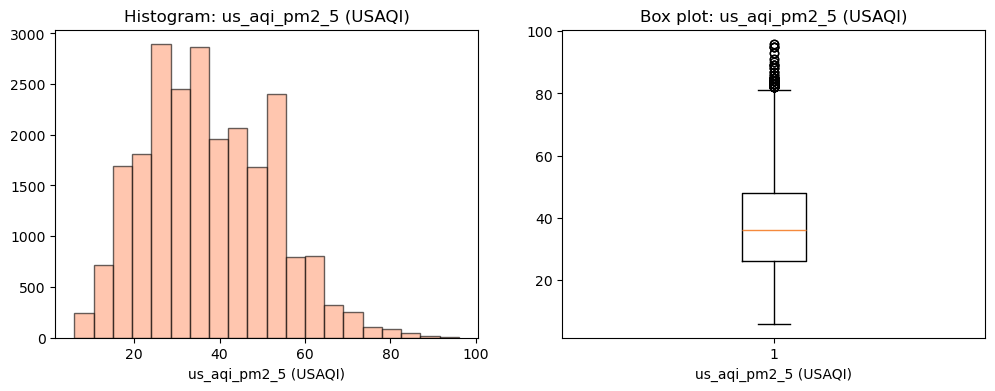

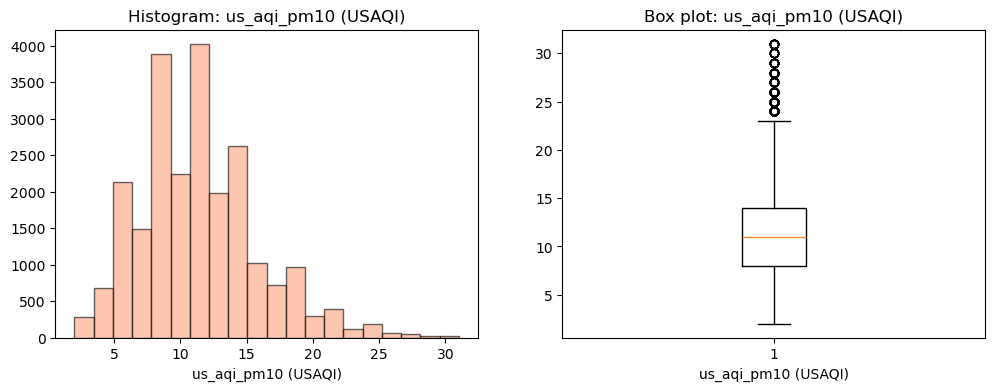

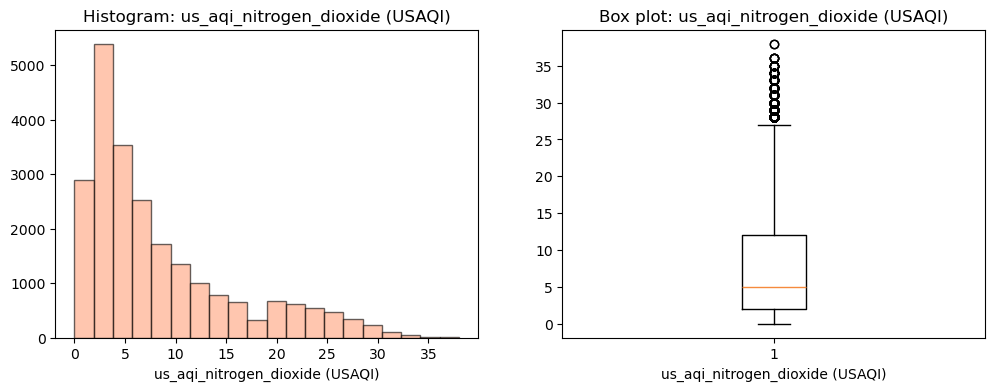

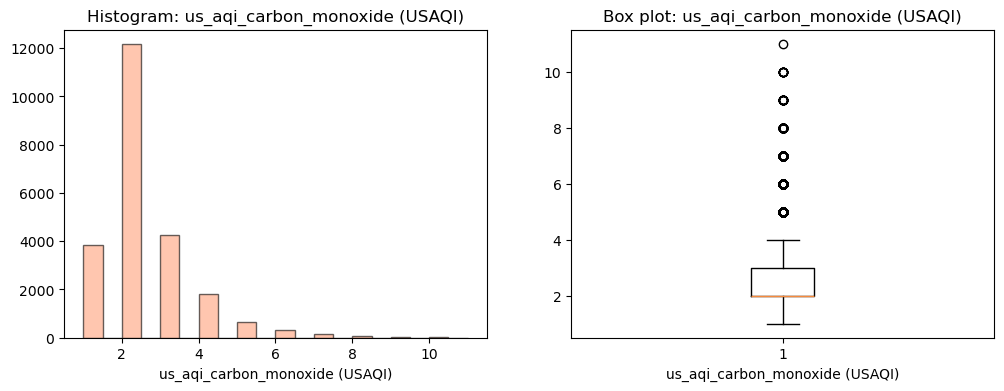

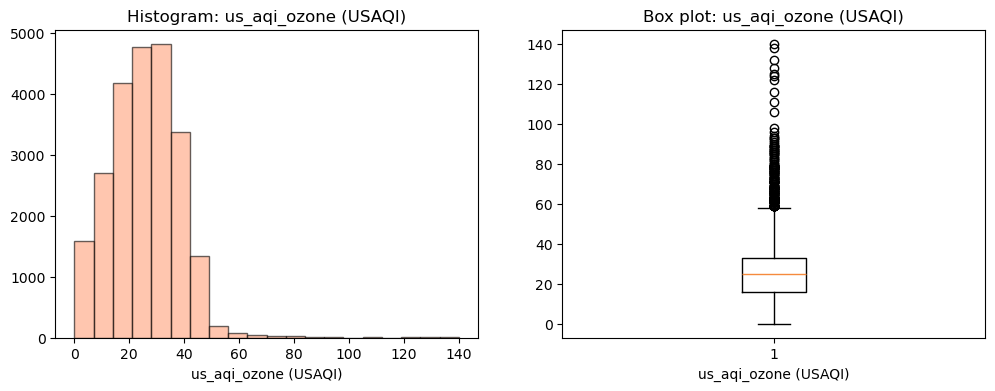

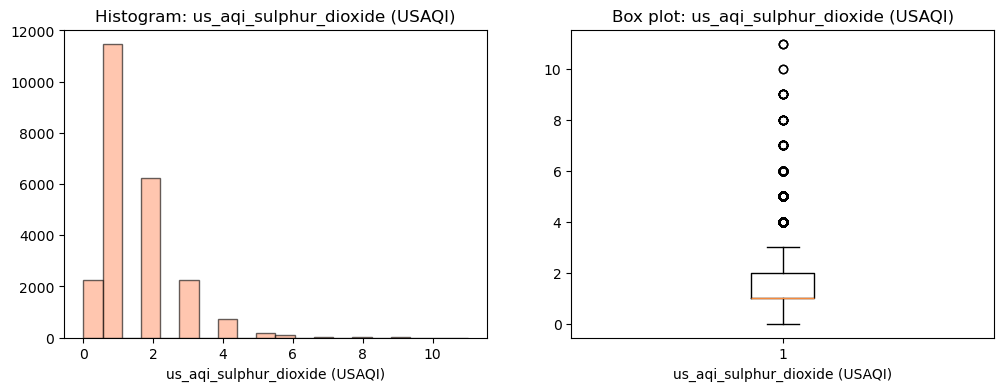

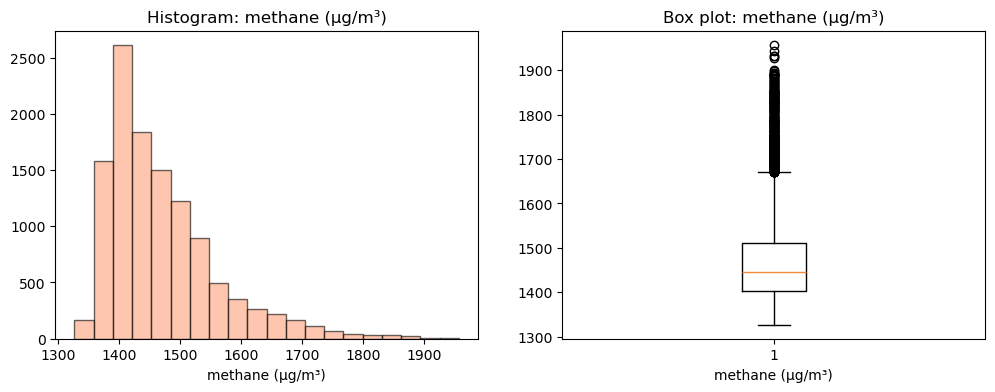

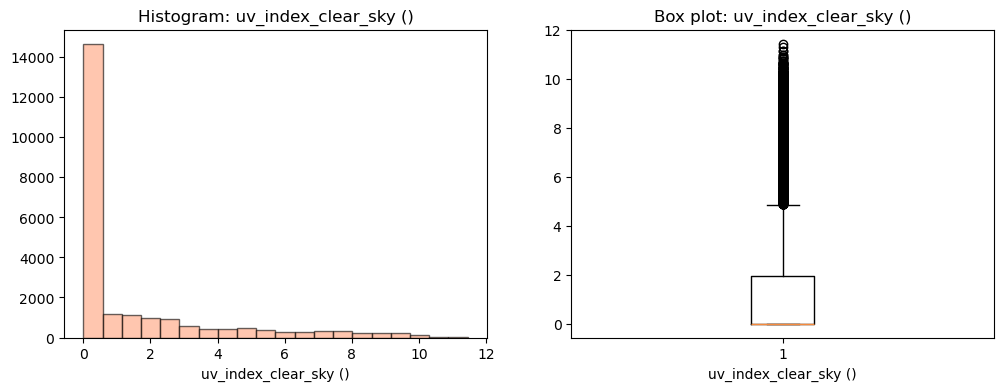

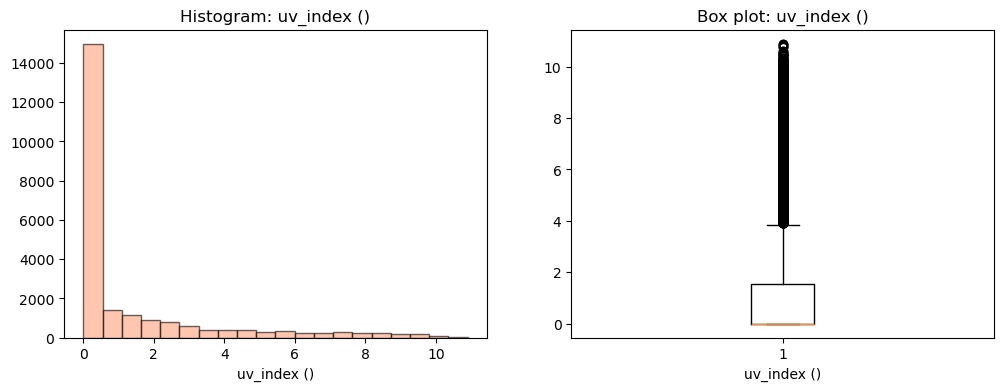

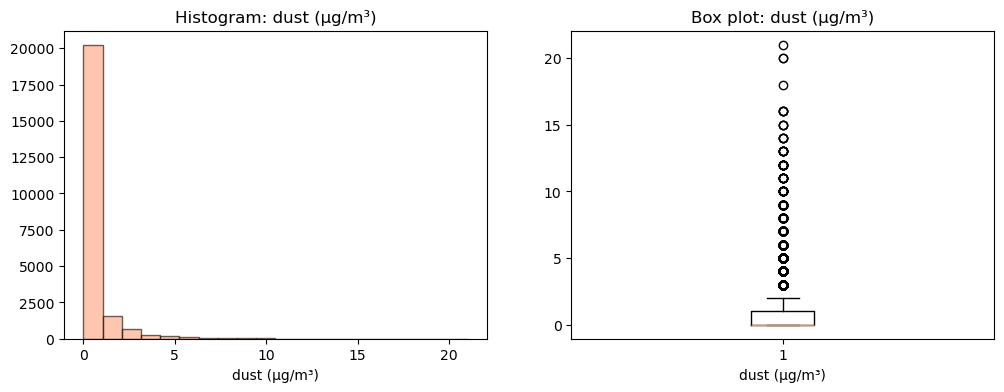

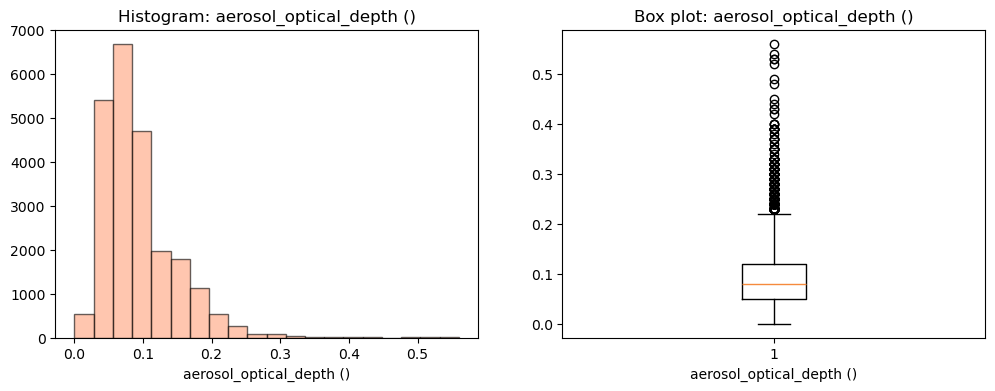

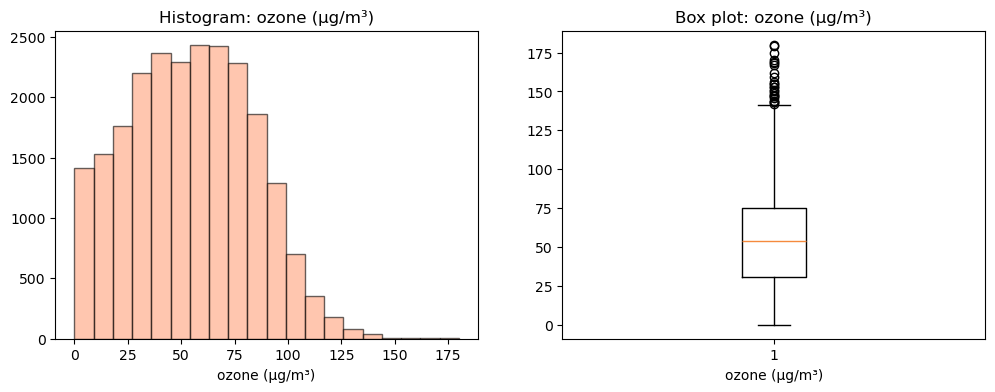

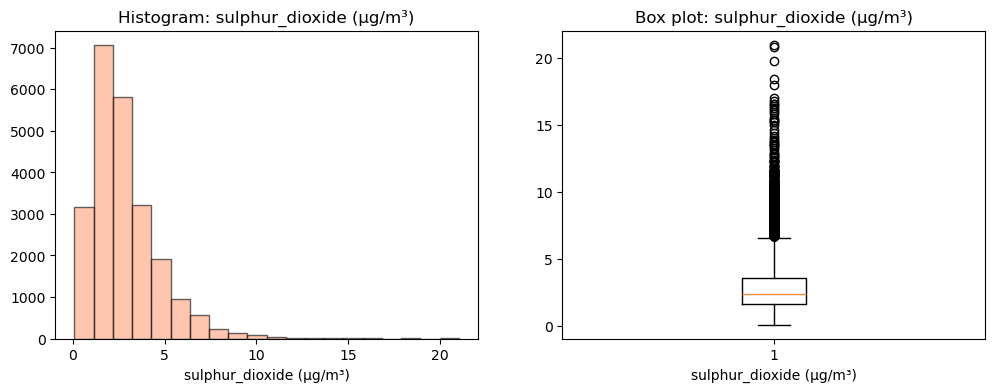

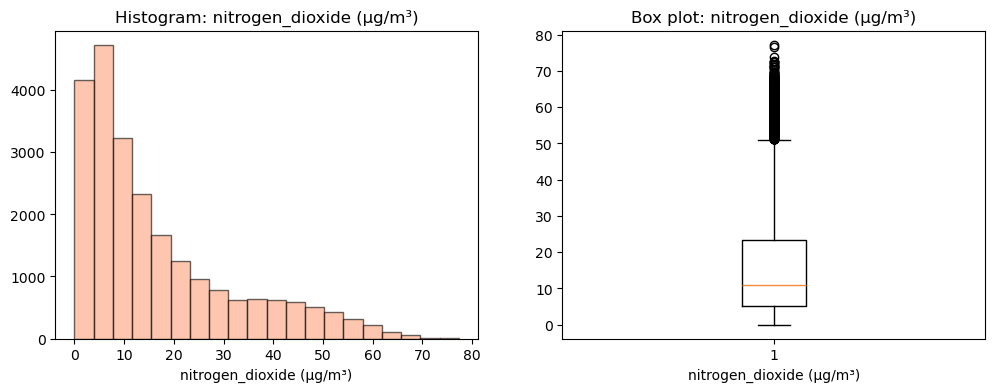

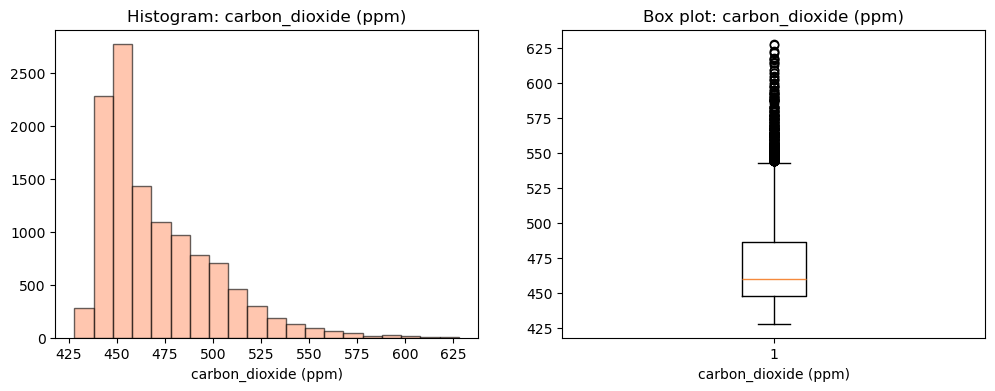

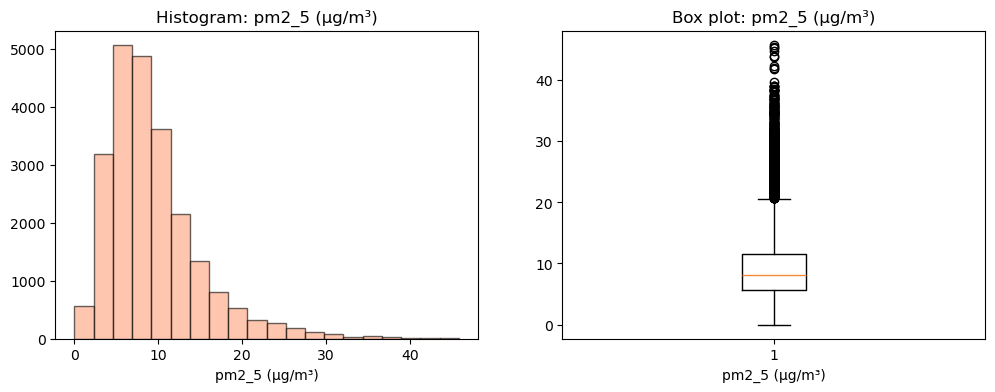

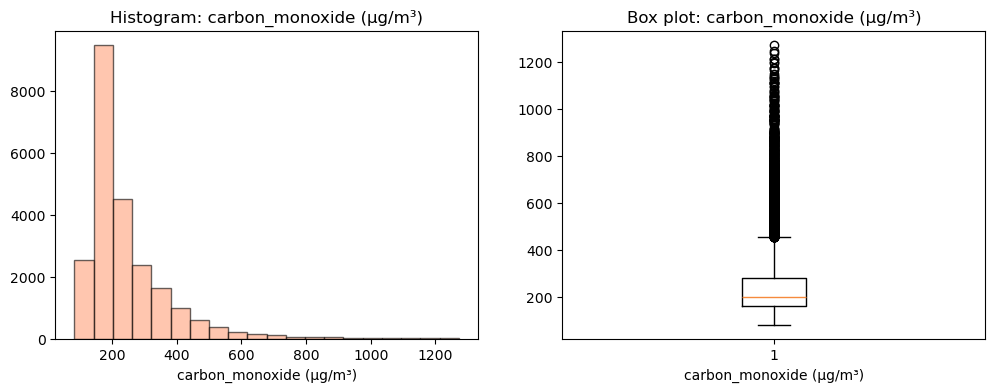

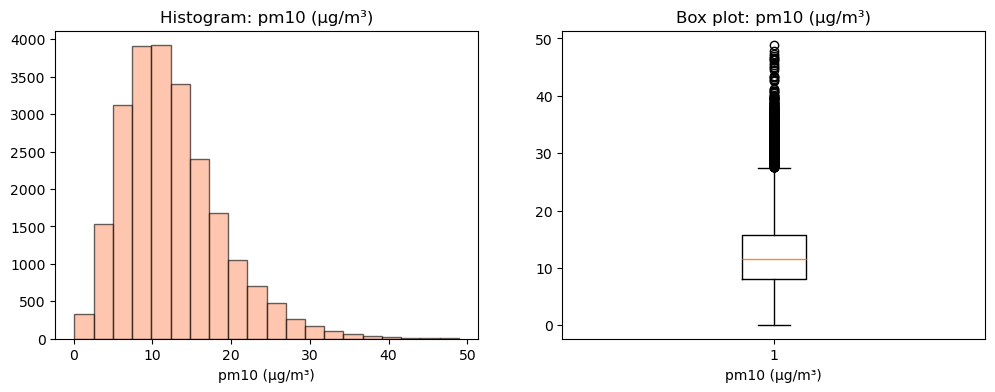

In [7]:
visualize_distribution(aq)

## Correlate air quality features

Identify which features move together. The top 5-8 features will be picked for use in data mining.

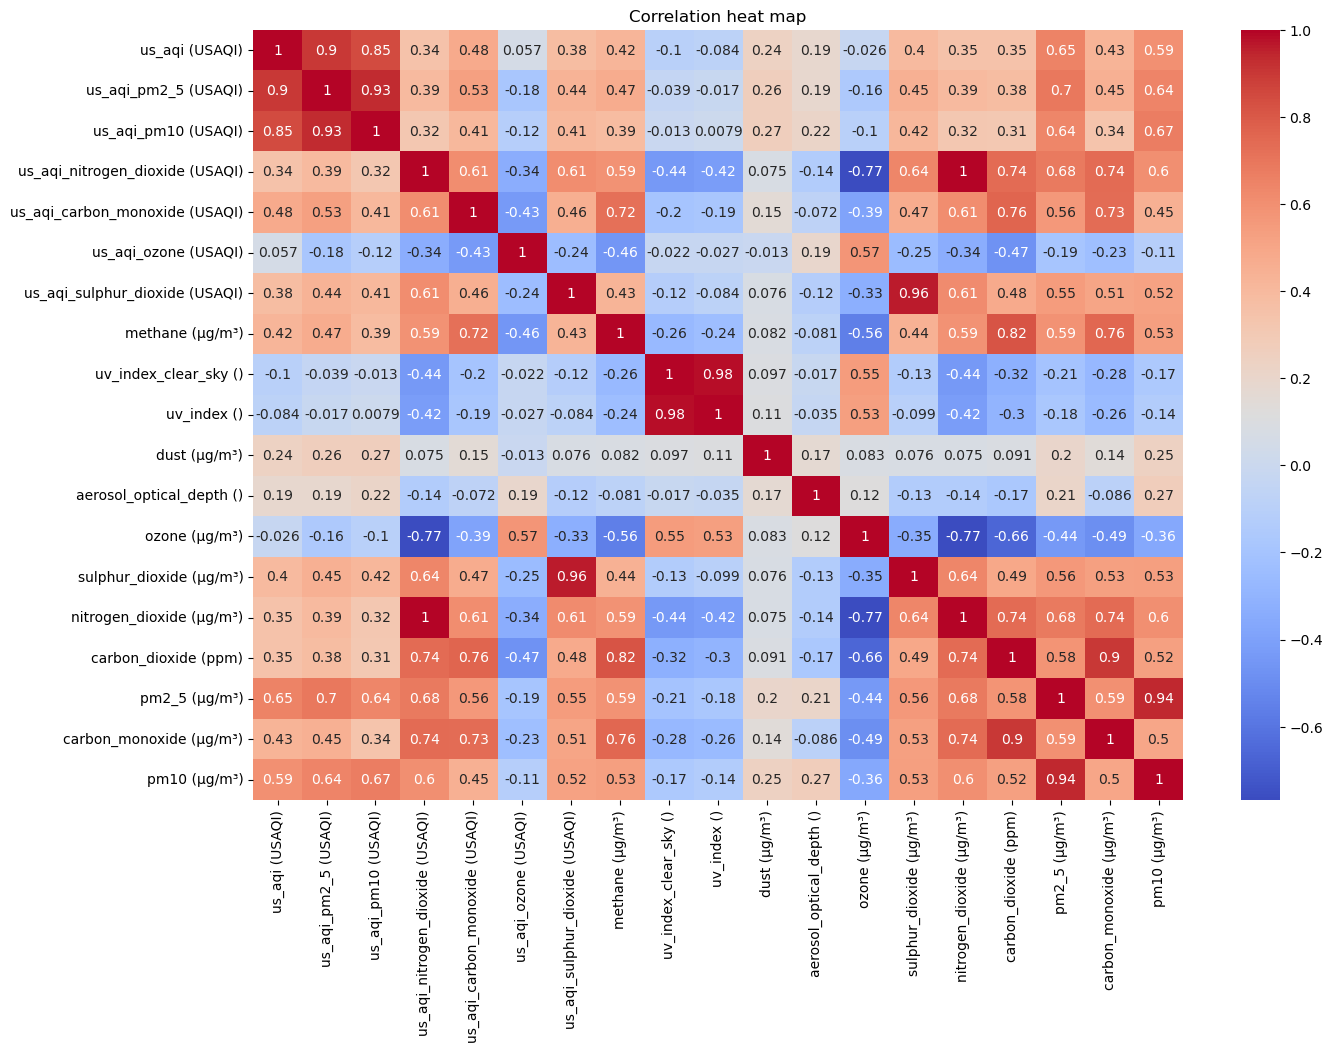

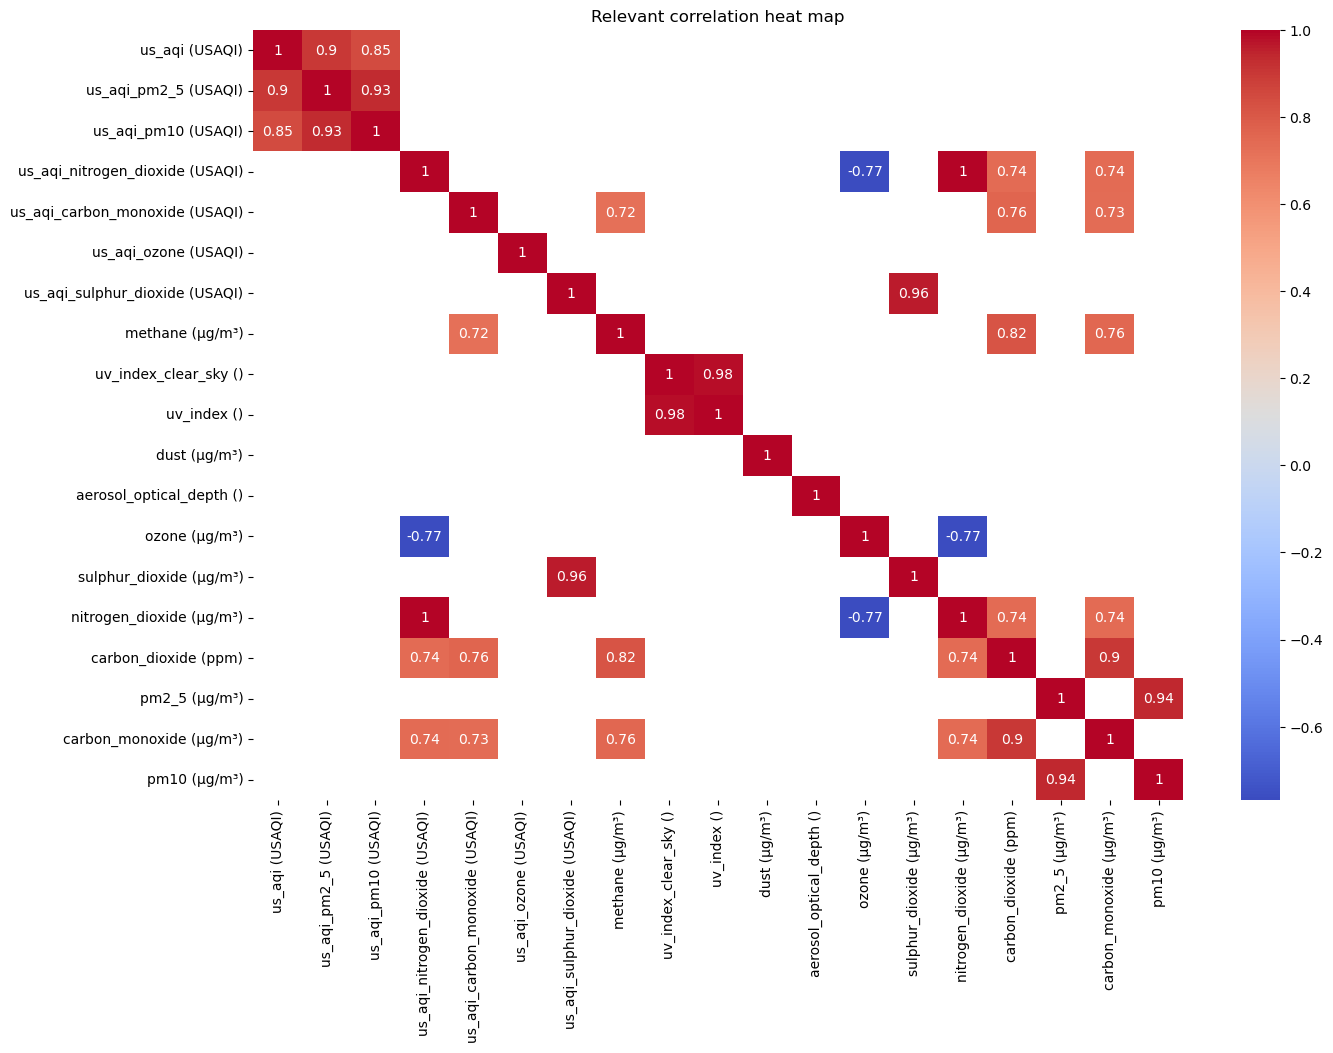

In [8]:
correlate_features(aq)

### Findings

- 'us_aqi (USAQI)' correlates heavily with 'us_aqi_pm2_5 (USAQI)' (0.9), and 'us_aqi_pm10 (USAQI)' (0.85)
- 'us_aqi_pm2_5 (USAQI)' correlates heavily with 'us_aqi_pm10 (USAQI)' (0.93)
- 'us_aqi_sulphur_dioxide (USAQI)' correlates heavily with 'sulphur_dioxide (μg/m³)' (0.96)
- 'methane (μg/m³)' correlates heavily with 'carbon_dioxide (ppm)' (0.82)
- 'uv_index_clear_sky ()' correlates heavily with 'uv_index ()' (0.98)
- 'carbon_dioxide (ppm)' correlates heavily with 'carbon_monoxide (μg/m³)' (0.9)
- 'pm2_5 (μg/m³)' correlates heavily with 'pm10 (μg/m³)' (0.94)

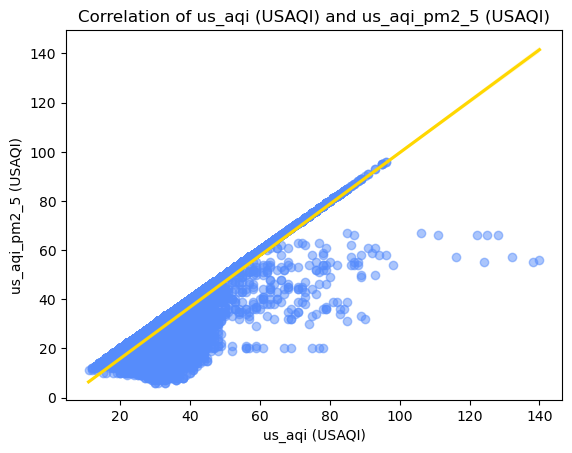

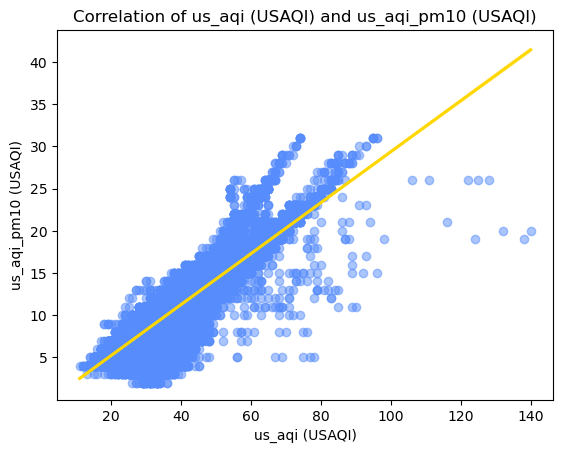

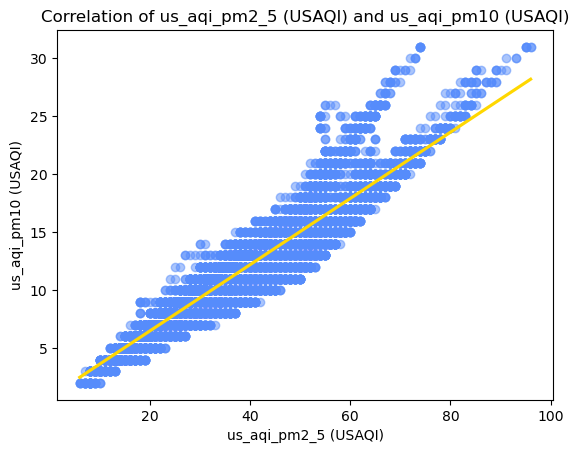

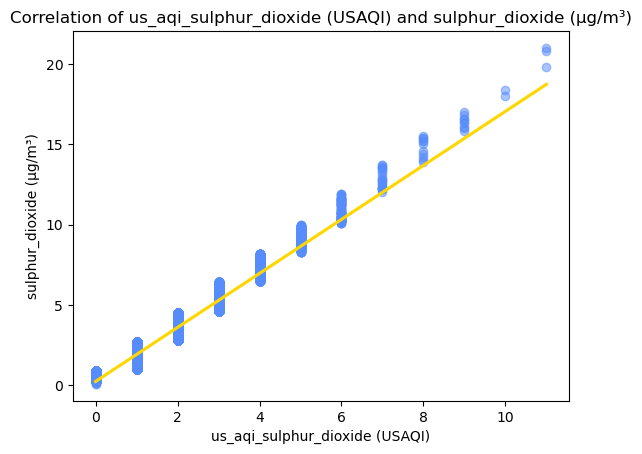

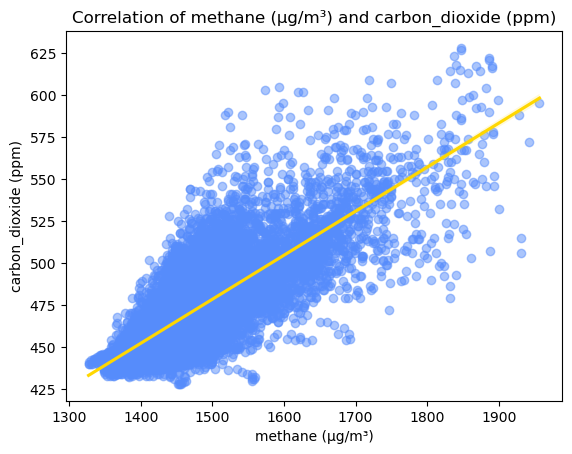

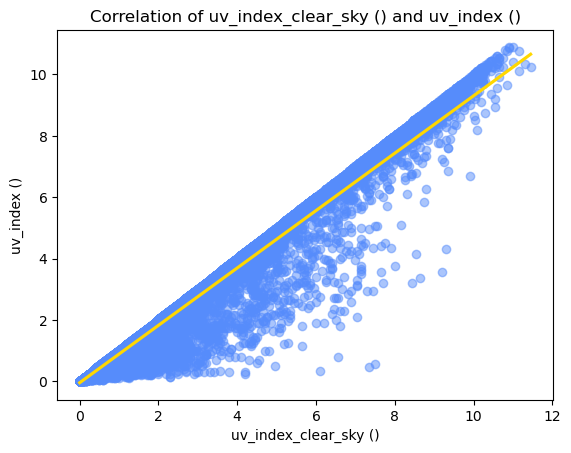

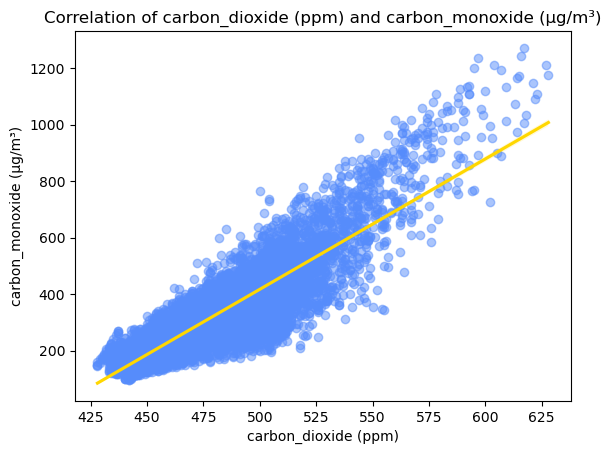

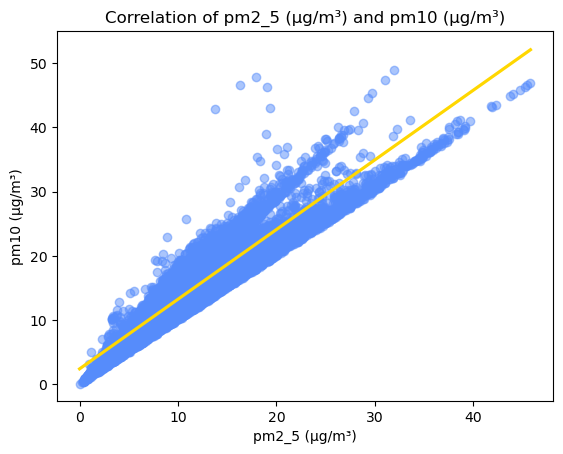

In [9]:
scatter_plot_features(aq, [
    [aq_keys['us_aqi (USAQI)'], aq_keys['us_aqi_pm2_5 (USAQI)']],
    [aq_keys['us_aqi (USAQI)'], aq_keys['us_aqi_pm10 (USAQI)']],
    [aq_keys['us_aqi_pm2_5 (USAQI)'], aq_keys['us_aqi_pm10 (USAQI)']],
    [aq_keys['us_aqi_sulphur_dioxide (USAQI)'], aq_keys['sulphur_dioxide (μg/m³)']],
    [aq_keys['methane (μg/m³)'], aq_keys['carbon_dioxide (ppm)']],
    [aq_keys['uv_index_clear_sky ()'], aq_keys['uv_index ()']],
    [aq_keys['carbon_dioxide (ppm)'], aq_keys['carbon_monoxide (μg/m³)']],
    [aq_keys['pm2_5 (μg/m³)'], aq_keys['pm10 (μg/m³)']] 
])

## Checkpoint

In [10]:
aq.to_csv(files['data/03-26-open-meteo-pre-narrowed.csv'], index=False)